# Rail Delay Prediction

Predicts rail service delays caused by nearby road closures.

**Structure**: All data loading, geo matching, and feature engineering lives in `src/`.
This notebook contains EDA, visualisation, model training, and prediction.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures", exist_ok=True)
%matplotlib inline

## 1. Load data

In [2]:
from datetime import datetime, timezone
from src.data_loader import (
    load_road_closures,
    load_stations,
    load_stations_lookup,
    load_train_moment_files,
    parse_train_moments,
    load_darwin_timetable,
)

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 12, 23, 59, 59, tzinfo=timezone.utc)

In [3]:
# Station lookup (TIPLOC / STANOX / 3ALPHA mapping)
lookup_df = load_stations_lookup()

# Train moments
train_files = load_train_moment_files(START, END)
train_moments_df = parse_train_moments(train_files, lookup_df)

print(f"Train moments loaded: {len(train_moments_df):,} rows")
train_moments_df.head()

No local files found. Fetching from Azure...
Connected to container: train-moments
Downloaded 360 blob(s) to 'data\train'
Train moments loaded: 41,026 rows


,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,situation_id,record_id,start_time,end_time,validity_status,cause_type,source,road_name,lanes_closed,closure_lat,closure_lon,poslist,ingestion_time,station_code
0,015H562C10,2026-04-10 08:15:00,2026-04-10 08:20:30,2026-04-10 08:20:00,1008.0,NaN,DEPARTURE,DEPARTURE,EARLY,5.0,NaN,NaN,NaN,True,True,1.775811e+12,SDR,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1.775811e+12,SMART,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RYH
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1.775811e+12,SMART,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BMD
3,525E20MF10,2026-04-10 09:47:00,NaT,NaT,52705.0,NaN,ARRIVAL,ARRIVAL,OFF ROUTE,0.0,NaN,NaN,NaN,False,False,1.775811e+12,SMART,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LHS
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1.775811e+12,SMART,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WST


In [5]:
# Drop road-closure columns that leaked into train-moment blobs
drop_cols = [
    "situation_id", "record_id", "start_time", "end_time",
    "validity_status", "cause_type", "source", "road_name",
    "lanes_closed", "closure_lat", "closure_lon", "poslist", "ingestion_time",
]
raw_train_moments_df = train_moments_df.drop(
    columns=[c for c in drop_cols if c in train_moments_df.columns]
)

# Drop rows where both timestamps are missing
raw_train_moments_df = raw_train_moments_df.dropna(
    subset=["actual_timestamp", "planned_timestamp"], how="all"
)
print(f"After cleanup: {len(raw_train_moments_df):,} rows")
raw_train_moments_df.head()

After cleanup: 39,091 rows


,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code
0,015H562C10,2026-04-10 08:15:00,2026-04-10 08:20:30,2026-04-10 08:20:00,1008.0,NaN,DEPARTURE,DEPARTURE,EARLY,5.0,NaN,NaN,NaN,True,True,1.775811e+12,SDR,0.0,
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1.775811e+12,SMART,0.0,RYH
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1.775811e+12,SMART,0.0,BMD
3,525E20MF10,2026-04-10 09:47:00,NaT,NaT,52705.0,NaN,ARRIVAL,ARRIVAL,OFF ROUTE,0.0,NaN,NaN,NaN,False,False,1.775811e+12,SMART,0.0,LHS
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1.775811e+12,SMART,1.0,WST


In [10]:
# Road closures
road_df = load_road_closures(START, END)
print(f"Road closures: {len(road_df):,} rows")
print(f"Validity statuses: {road_df.validity_status.unique()}")
display(road_df.head())

# Stations
stations_df = load_stations()
print(f"Stations: {len(stations_df):,}")
display(stations_df.head())

No local files found. Fetching from Azure...
Connected to container: road-closures
Downloaded 4 blob(s) to 'data\road'
Road closures: 296 rows
Validity statuses: <StringArray>
['planned', 'active', 'suspended']
Length: 3, dtype: str


,situation_id,record_id,start_time,end_time,validity_status,cause_type,source,road_name,lanes_closed,closure_lat,closure_lon,poslist,ingestion_time,closure_type
0,481398,1-1770230430-d6ff48ca-8971-4f31-831f-272231753b8a,2026-04-11T19:00:00Z,2026-04-12T05:00:00Z,planned,roadMaintenance,roadworks,M11,2,52.241032,0.056728,['52.237974 0.062705 52.237644 0.063174 52.237...,2026-04-11 05:09:20.728518,planned
1,481398,1-1770230430-ee17da45-7781-4cee-85b8-1958b86f1b72,2026-04-11T19:00:00Z,2026-04-12T05:00:00Z,planned,roadMaintenance,roadworks,A14,1,52.240029,0.059073,['52.240826 0.057497 52.240366 0.058604 52.239...,2026-04-11 05:09:20.728567,planned
2,481398,1-1770230430-acff749b-b497-4d6f-a60f-01677b02af5c,2026-04-09T19:00:00Z,2026-04-10T05:00:00Z,planned,roadMaintenance,roadworks,A14,2,52.260536,0.016397,['52.257609 0.023547 52.257608 0.023549 52.257...,2026-04-11 05:09:20.728631,planned
3,481533,1-1770819974-8fa8f569-45d0-4710-a6df-39f3d37e1c3d,2026-04-09T19:00:00Z,2026-04-10T05:00:00Z,planned,roadMaintenance,roadworks,M1,3,52.847611,-1.298524,['52.855638 -1.299951 52.855692 -1.299979 52.8...,2026-04-11 05:09:20.728723,planned
4,470844,1-1770730368-f293b6be-d3b5-410b-9fc8-9761a531e558,2026-04-10T08:00:00Z,2026-04-10T14:00:00Z,planned,roadMaintenance,roadworks,A36,1,51.075089,-1.787852,['51.075752 -1.790037 51.075673 -1.78978 51.07...,2026-04-11 05:09:20.728744,planned


Stations: 2,595


,Station,Postcode,Latitude,Longitude,TLC,NLC,Owner,Entries and exits 2025,Entries and exits 2024,Entries and exits 2023,Entries and exits 2022,Entries and exits 2021,Entries and exits 2020,Entries and exits 2019,Entries and exits 2018,Entries and exits 2017,Entries and exits 2016,Entries and exits 2015,Entries and exits 2014,Entries and exits 2013,...,Interchanges 2024,Interchanges 2023,Interchanges 2022,Interchanges 2021,Interchanges 2020,Interchanges 2019,Interchanges 2018,Interchanges 2017,Interchanges 2016,Interchanges 2015,Interchanges 2014,Interchanges 2013,Interchanges 2012,Interchanges 2011,Interchanges 2010,Interchanges 2009,Interchanges 2008,Interchanges 2007,Interchanges 2006,Interchanges 2005
0,Abbey Wood,SE2 9RH,51.491061,0.121394,ABW,5131.0,TfL Rail,11873686.0,10655006.0,7118664.0,2638456.0,1412638.0,3825206.0,3769402.0,3124856.0,2988802.0,2929472.0,3319408.0,3282240.0,3175430.0,...,1888592.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Aber,CF83 1AQ,51.574969,-3.229829,ABE,3813.0,TfW Rail,145234.0,136896.0,103976.0,73642.0,15712.0,228480.0,245218.0,251108.0,227270.0,214996.0,212546.0,219868.0,209622.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Abercynon,CF45 4SE,51.644712,-3.326989,ACY,3801.0,TfW Rail,189820.0,144514.0,134880.0,105822.0,33006.0,282886.0,289008.0,298358.0,293638.0,275404.0,265458.0,251688.0,243948.0,...,15129.0,15581.0,11592.0,1887.0,29079.0,33607.0,36440.0,42087.0,41720.0,40847.0,42347.0,35871.0,35304.0,33225.0,29324.0,28775.0,NaN,NaN,NaN,NaN
3,Aberdare,CF44 0PU,51.715062,-3.443084,ABA,3982.0,TfW Rail,341438.0,238580.0,226714.0,177350.0,53668.0,504622.0,555780.0,571746.0,569364.0,566904.0,551928.0,557992.0,552436.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aberdeen,AB11 6LX,57.143706,-2.098685,ABD,8976.0,ScotRail,2377660.0,2287858.0,1961414.0,1536720.0,393982.0,2497108.0,2616142.0,2948186.0,3058268.0,3459944.0,3742646.0,3599431.0,3338072.0,...,202181.0,179272.0,124666.0,27863.0,237220.0,258416.0,179958.0,192344.0,204139.0,219002.0,219085.0,200864.0,197046.0,148594.0,164299.0,162526.0,119259.0,230788.0,201417.0,187983.0


## 2. Match closures to nearby stations

In [11]:
from src.geo import find_nearby_stations

expanded_road_df = find_nearby_stations(
    road_df, stations_df, lookup_df, min_km=10, max_km=25
)
print(f"Closure–station pairs: {len(expanded_road_df):,}")
expanded_road_df.head()

Closure–station pairs: 16,369


,closure_id,closure_lat,closure_lon,closure_type,closure_start_time,closure_end_time,validity_status,station_name,station_lat,station_lon,station_code,stanox,tpl,distance_in_km,road_ingestion_time
0,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Dullingham,52.201649,0.366664,DUL,47006,DULNGHM,21.561992,2026-04-11 05:09:20.728518
1,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Ely,52.391228,0.266828,ELY,46273,ELYY,21.974512,2026-04-11 05:09:20.728518
2,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Foxton,52.119212,0.056308,FXN,47242,FOXTON,13.545760,2026-04-11 05:09:20.728518
3,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Great Chesterford,52.059809,0.193521,GRC,47311,GTCHSFD,22.207451,2026-04-11 05:09:20.728518
4,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Huntingdon,52.328648,-0.192068,HUN,45201,HNTNGDN,19.527520,2026-04-11 05:09:20.728518


## 3. Merge with train moments & filter to 1-hour window

In [13]:
from src.features import (
    merge_on_station,
    merge_schedule_with_closures,
    reshape_timetable_to_schedule,
    filter_within_time_window,
    add_delay_column,
)

# Merge closures with train moments on station_code
road_train_moments_df = merge_on_station(expanded_road_df, raw_train_moments_df)
print(f"Merged: {len(expanded_road_df):,} closure pairs × train moments → {len(road_train_moments_df):,} rows")
display(road_train_moments_df.head())

Merged: 16,369 closure pairs × train moments → 241,458 rows


,closure_id,closure_lat,closure_lon,closure_type,closure_start_time,closure_end_time,validity_status,station_name,station_lat,station_lon,station_code,stanox,tpl,distance_in_km,road_ingestion_time,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed
0,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Ely,52.391228,0.266828,ELY,46273,ELYY,21.974512,2026-04-11 05:09:20.728518,541T26MJ10,2026-04-10 13:04:00,2026-04-10 13:04:00,2026-04-10 13:04:00,46273.0,46272.0,DEPARTURE,DEPARTURE,ON TIME,0.0,1,1.0,DOWN,False,True,1.775823e+12,SMART,0.0
1,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Ely,52.391228,0.266828,ELY,46273,ELYY,21.974512,2026-04-11 05:09:20.728518,471N55MK10,2026-04-10 13:16:00,2026-04-10 13:15:00,2026-04-10 13:15:00,46273.0,46272.0,DEPARTURE,DEPARTURE,LATE,1.0,1,1.0,DOWN,False,True,1.775823e+12,SMART,1.0
2,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Ely,52.391228,0.266828,ELY,46273,ELYY,21.974512,2026-04-11 05:09:20.728518,596L43CG10,2026-04-10 13:30:00,2026-04-10 13:07:30,NaT,46273.0,46275.0,DEPARTURE,DEPARTURE,LATE,23.0,2,3.0,UP,False,True,1.775824e+12,SMART,1.0
3,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Ely,52.391228,0.266828,ELY,46273,ELYY,21.974512,2026-04-11 05:09:20.728518,530Z682L10,2026-04-10 13:46:00,2026-04-10 13:51:00,NaT,46273.0,46272.0,ARRIVAL,ARRIVAL,EARLY,5.0,NaN,0.0,NaN,False,True,1.775825e+12,SMART,0.0
4,481398,52.241032,0.056728,planned,2026-04-11 19:00:00,2026-04-12 05:00:00,planned,Ely,52.391228,0.266828,ELY,46273,ELYY,21.974512,2026-04-11 05:09:20.728518,461T35MN10,2026-04-10 13:51:00,2026-04-10 13:51:00,2026-04-10 13:51:00,46273.0,46275.0,DEPARTURE,DEPARTURE,ON TIME,0.0,3,2.0,UP,False,True,1.775825e+12,SMART,0.0


In [14]:
# Filter to within 60 minutes after closure start
filtered_train_moments_df = filter_within_time_window(road_train_moments_df, window_minutes=60)

# Select relevant columns
filtered_train_moments_df = filtered_train_moments_df[[
    "closure_id", "closure_type", "closure_lat", "closure_lon",
    "distance_in_km", "station_name", "stanox",
    "closure_start_time", "actual_timestamp", "planned_timestamp",
    "planned_time_diff", "event_type",
]].copy()

print(f"Filtered train moments: {len(filtered_train_moments_df):,} rows")

print("\nBy closure type:")
display(filtered_train_moments_df.groupby("closure_type").size())

print("\nBy event type:")
display(filtered_train_moments_df.groupby("event_type").size())

Filtered train moments: 4,914 rows

By closure type:


closure_type
planned      2201
unplanned    2713
dtype: int64


By event type:


event_type
ARRIVAL      2402
DEPARTURE    2512
dtype: int64

## 3b. Build timetable schedule & filter

In [15]:
timetable_df = load_darwin_timetable()
schedule_df = reshape_timetable_to_schedule(timetable_df, lookup_df)

# Merge with expanded road closures on stanox
merged_schedule = merge_schedule_with_closures(expanded_road_df, schedule_df)

# Filter to 1-hour window
filtered_timetable_df = filter_within_time_window(merged_schedule, window_minutes=60)

filtered_timetable_df = filtered_timetable_df[[
    "closure_id", "closure_type", "closure_lat", "closure_lon",
    "distance_in_km", "station_name", "stanox",
    "closure_start_time", "planned_timestamp", "planned_time_diff", "event_type",
]].copy()

print(f"Filtered timetable rows: {len(filtered_timetable_df):,}")

Connected to container: darwin-timetable-feeds
Processing: PPTimetable_20260410020459_v8.xml
Processing: PPTimetable_20260412020459_v8.xml
Processing data\darwin_timetable\PPTimetable_20260410020459_v8.json with 65734 journeys
Processing data\darwin_timetable\PPTimetable_20260412020459_v8.json with 55999 journeys
Filtered timetable rows: 184,592


## 3c. Data quality check

In [16]:
# Ensure consistent dtypes
filtered_train_moments_df["planned_timestamp"] = filtered_train_moments_df["planned_timestamp"].astype("datetime64[ns]")
filtered_train_moments_df["actual_timestamp"] = filtered_train_moments_df["actual_timestamp"].astype("datetime64[ns]")
filtered_timetable_df["planned_timestamp"] = filtered_timetable_df["planned_timestamp"].astype("datetime64[ns]")

print(f"Train moments — planned not null: {filtered_train_moments_df['planned_timestamp'].notna().sum():,}, "
      f"actual not null: {filtered_train_moments_df['actual_timestamp'].notna().sum():,}")
print(f"Timetable    — planned not null: {filtered_timetable_df['planned_timestamp'].notna().sum():,}")

filtered_train_moments_df.info()

Train moments — planned not null: 4,914, actual not null: 4,914
Timetable    — planned not null: 184,592
<class 'pandas.DataFrame'>
Index: 4914 entries, 727 to 237058
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   closure_id          4914 non-null   object        
 1   closure_type        4914 non-null   str           
 2   closure_lat         4914 non-null   float64       
 3   closure_lon         4914 non-null   float64       
 4   distance_in_km      4914 non-null   float64       
 5   station_name        4914 non-null   str           
 6   stanox              4914 non-null   str           
 7   closure_start_time  4914 non-null   datetime64[us]
 8   actual_timestamp    4914 non-null   datetime64[ns]
 9   planned_timestamp   4914 non-null   datetime64[ns]
 10  planned_time_diff   4914 non-null   float64       
 11  event_type          4914 non-null   str           
dtypes: datetime

## 4. Compute delay & feature interactions

In [18]:
# Delay = actual - planned (minutes)
filtered_train_moments_df["delay"] = (
    filtered_train_moments_df["actual_timestamp"] - filtered_train_moments_df["planned_timestamp"]
).dt.total_seconds() / 60

# Feature interaction
filtered_train_moments_df["distance_time_interaction"] = (
    filtered_train_moments_df["distance_in_km"] * filtered_train_moments_df["planned_time_diff"]
)
filtered_timetable_df["distance_time_interaction"] = (
    filtered_timetable_df["distance_in_km"] * filtered_timetable_df["planned_time_diff"]
)

## 5. EDA — Dataset summary

In [19]:
print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)
print(f"Training set size: {len(filtered_train_moments_df):,} rows")
print(f"Date range: {filtered_train_moments_df['planned_timestamp'].min()} → "
      f"{filtered_train_moments_df['planned_timestamp'].max()}")
print(f"Unique stations: {filtered_train_moments_df['station_name'].nunique()}")

closure_events = filtered_train_moments_df.groupby(
    ["closure_start_time", "closure_lat", "closure_lon"]
).size()
print(f"Unique closure events: {len(closure_events)}")

print("\n" + "=" * 80)
print("DELAY STATISTICS")
print("=" * 80)
print(filtered_train_moments_df["delay"].describe())
print(f"\nSkewness: {filtered_train_moments_df['delay'].skew():.4f}")
print(f"Kurtosis: {filtered_train_moments_df['delay'].kurtosis():.4f}")

print("\n" + "=" * 80)
print("PREDICTOR STATISTICS")
print("=" * 80)
for col, unit in [("distance_in_km", "km"), ("planned_time_diff", "min")]:
    s = filtered_train_moments_df[col]
    print(f"\n{col}: median={s.median():.2f} {unit}, mean={s.mean():.2f} {unit}, "
          f"range=[{s.min():.2f}, {s.max():.2f}]")

DATASET SUMMARY
Training set size: 4,914 rows
Date range: 2026-04-09 21:56:30 → 2026-04-12 22:59:00
Unique stations: 795
Unique closure events: 144

DELAY STATISTICS
count    4914.000000
mean        1.042735
std         5.784102
min      -104.000000
25%        -0.500000
50%         0.000000
75%         1.500000
max        61.500000
Name: delay, dtype: float64

Skewness: -3.1076
Kurtosis: 87.9887

PREDICTOR STATISTICS

distance_in_km: median=19.64 km, mean=19.11 km, range=[10.02, 25.00]

planned_time_diff: median=29.71 min, mean=30.21 min, range=[0.01, 60.00]


## 5a. Delay distribution

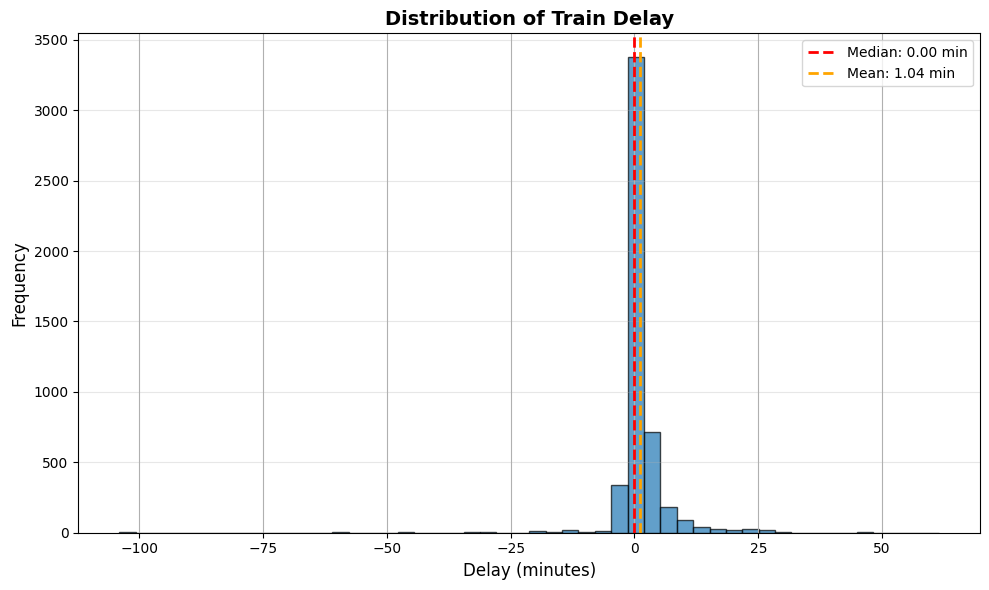

In [20]:
plt.figure(figsize=(10, 6))
filtered_train_moments_df["delay"].hist(bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Delay (minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Train Delay", fontsize=14, fontweight="bold")
median_val = filtered_train_moments_df["delay"].median()
mean_val = filtered_train_moments_df["delay"].mean()
plt.axvline(median_val, color="red", linestyle="--", lw=2, label=f"Median: {median_val:.2f} min")
plt.axvline(mean_val, color="orange", linestyle="--", lw=2, label=f"Mean: {mean_val:.2f} min")
plt.legend(fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_4_1_delay_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

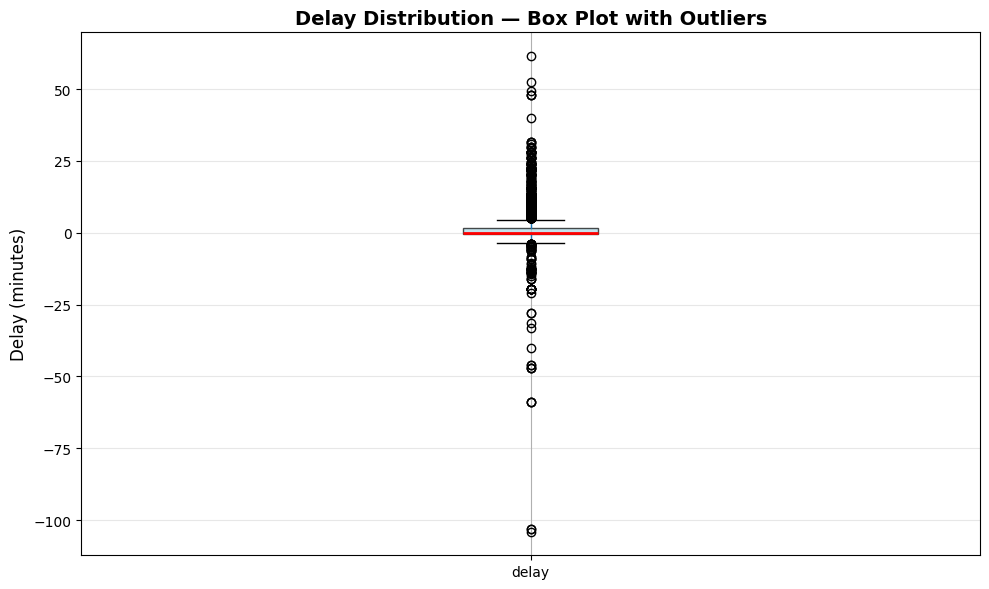


Delay quantiles:
0.01   -12.0
0.05    -1.5
0.25    -0.5
0.50     0.0
0.75     1.5
0.95     8.5
0.99    22.5
Name: delay, dtype: float64


In [21]:
plt.figure(figsize=(10, 6))
filtered_train_moments_df.boxplot(
    column="delay", vert=True, patch_artist=True,
    boxprops=dict(facecolor="lightblue", alpha=0.7),
    medianprops=dict(color="red", linewidth=2),
)
plt.ylabel("Delay (minutes)", fontsize=12)
plt.title("Delay Distribution — Box Plot with Outliers", fontsize=14, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_4_2_delay_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nDelay quantiles:")
print(filtered_train_moments_df["delay"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

In [22]:
# Outlier investigation
extreme_early = filtered_train_moments_df[filtered_train_moments_df["delay"] < -30]
extreme_late = filtered_train_moments_df[filtered_train_moments_df["delay"] > 30]

print(f"Extreme early (< -30 min): {len(extreme_early):,} ({len(extreme_early)/len(filtered_train_moments_df)*100:.2f}%)")
print(f"Extreme late  (> 30 min):  {len(extreme_late):,} ({len(extreme_late)/len(filtered_train_moments_df)*100:.2f}%)")

if len(extreme_late) > 0:
    print("\nSample extreme late arrivals:")
    display(extreme_late[["station_name", "planned_timestamp", "actual_timestamp", "delay"]].head(10))

Extreme early (< -30 min): 14 (0.28%)
Extreme late  (> 30 min):  11 (0.22%)

Sample extreme late arrivals:


,station_name,planned_timestamp,actual_timestamp,delay
776,Cardiff Central,2026-04-10 19:25:00,2026-04-10 20:05:00,40.0
66216,Shortlands,2026-04-12 21:30:30,2026-04-12 22:23:00,52.5
70486,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5
70777,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5
71065,Kirk Sandall,2026-04-12 19:31:30,2026-04-12 20:03:00,31.5
124430,Battersea Park,2026-04-10 23:17:30,2026-04-11 00:19:00,61.5
124431,Battersea Park,2026-04-10 23:32:30,2026-04-11 00:22:00,49.5
159456,Bromley South,2026-04-10 13:30:00,2026-04-10 14:01:00,31.0
194190,Garforth,2026-04-10 12:39:00,2026-04-10 13:27:00,48.0
202020,Garforth,2026-04-10 12:39:00,2026-04-10 13:27:00,48.0


## 5b. Categorical distributions

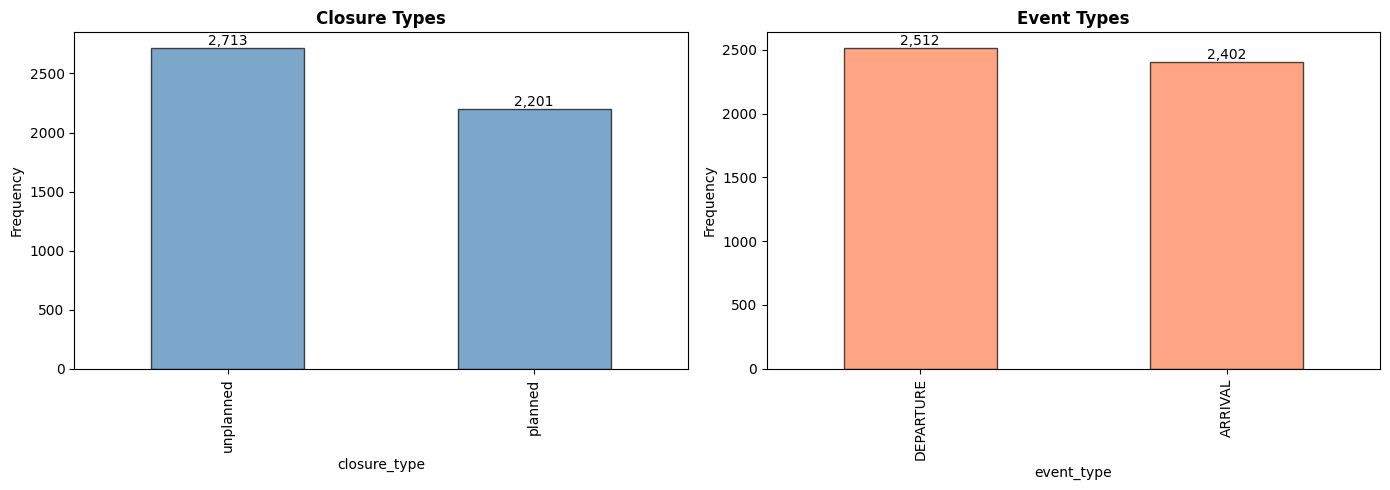

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Closure type
counts = filtered_train_moments_df["closure_type"].value_counts()
counts.plot(kind="bar", color="steelblue", edgecolor="black", alpha=0.7, ax=axes[0])
axes[0].set_title("Closure Types", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Frequency")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts) * 0.01, f"{v:,}", ha="center", fontsize=10)

# Event type
counts_e = filtered_train_moments_df["event_type"].value_counts()
counts_e.plot(kind="bar", color="coral", edgecolor="black", alpha=0.7, ax=axes[1])
axes[1].set_title("Event Types", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Frequency")
for i, v in enumerate(counts_e.values):
    axes[1].text(i, v + max(counts_e) * 0.01, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("figures/fig_4_3_categorical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## 5c. Predictor distributions

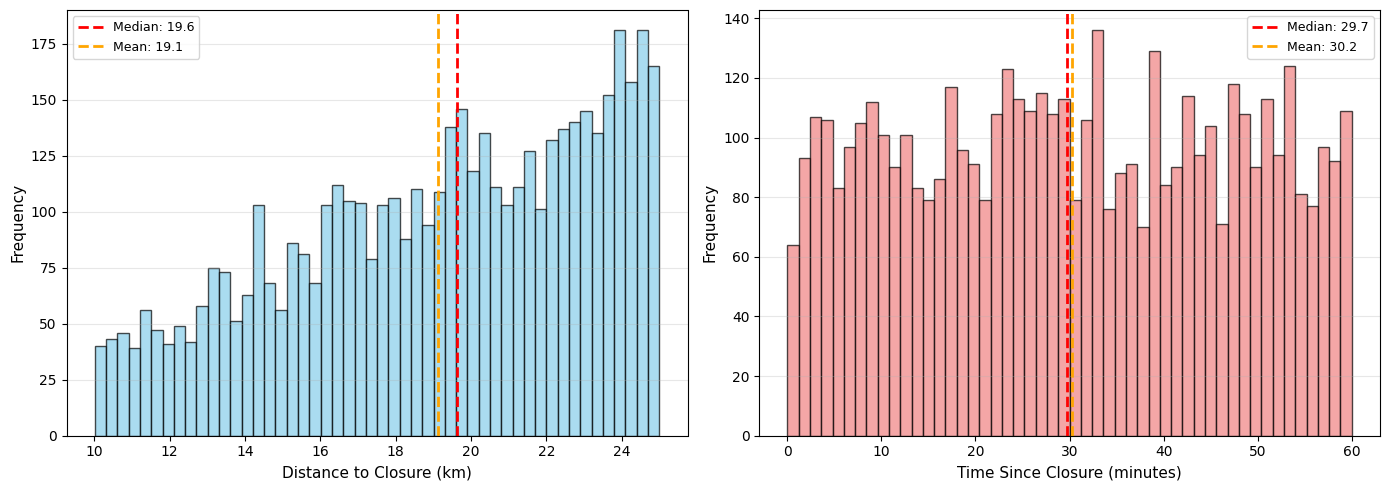

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, label in [
    (axes[0], "distance_in_km", "skyblue", "Distance to Closure (km)"),
    (axes[1], "planned_time_diff", "lightcoral", "Time Since Closure (minutes)"),
]:
    s = filtered_train_moments_df[col]
    ax.hist(s, bins=50, edgecolor="black", alpha=0.7, color=color)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.axvline(s.median(), color="red", linestyle="--", lw=2, label=f"Median: {s.median():.1f}")
    ax.axvline(s.mean(), color="orange", linestyle="--", lw=2, label=f"Mean: {s.mean():.1f}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig_4_5_predictor_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## 5d. Scatter plots — delay vs predictors

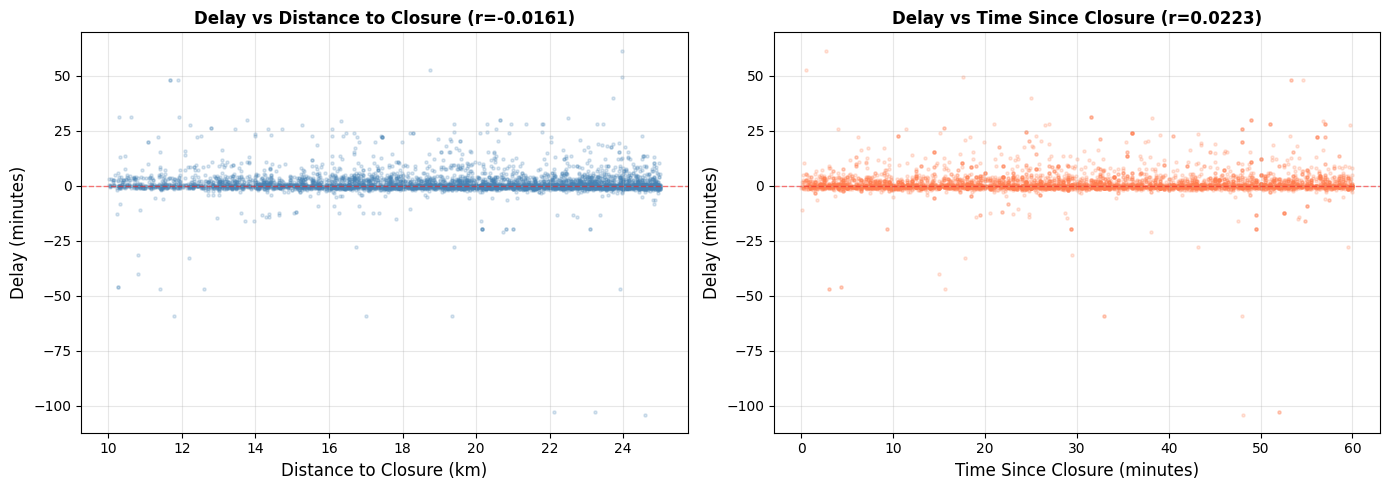

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color, xlabel in [
    (axes[0], "distance_in_km", "steelblue", "Distance to Closure (km)"),
    (axes[1], "planned_time_diff", "coral", "Time Since Closure (minutes)"),
]:
    ax.scatter(filtered_train_moments_df[col], filtered_train_moments_df["delay"],
               alpha=0.2, s=5, color=color)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Delay (minutes)", fontsize=12)
    ax.axhline(0, color="red", linestyle="--", lw=1, alpha=0.5)
    ax.grid(alpha=0.3)

    corr = filtered_train_moments_df[[col, "delay"]].corr().iloc[0, 1]
    ax.set_title(f"Delay vs {xlabel.split('(')[0].strip()} (r={corr:.4f})",
                 fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig_4_6_delay_vs_predictors.png", dpi=300, bbox_inches="tight")
plt.show()

## 5e. Heatmaps

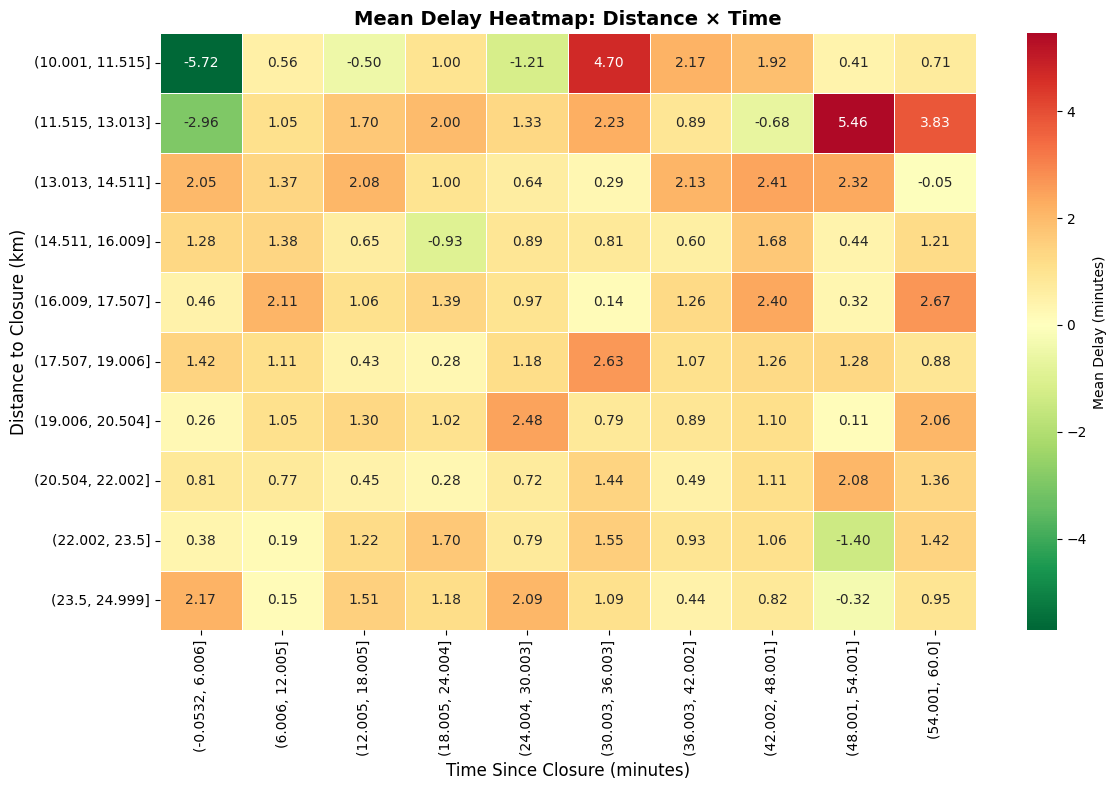

In [26]:
# Distance × time heatmap
hm = filtered_train_moments_df.copy()
hm["distance_bin"] = pd.cut(hm["distance_in_km"], bins=10)
hm["time_bin"] = pd.cut(hm["planned_time_diff"], bins=10)
pivot = hm.pivot_table(values="delay", index="distance_bin", columns="time_bin", aggfunc="mean")

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0,
            cbar_kws={"label": "Mean Delay (minutes)"}, linewidths=0.5)
plt.xlabel("Time Since Closure (minutes)", fontsize=12)
plt.ylabel("Distance to Closure (km)", fontsize=12)
plt.title("Mean Delay Heatmap: Distance × Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_4_8_delay_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

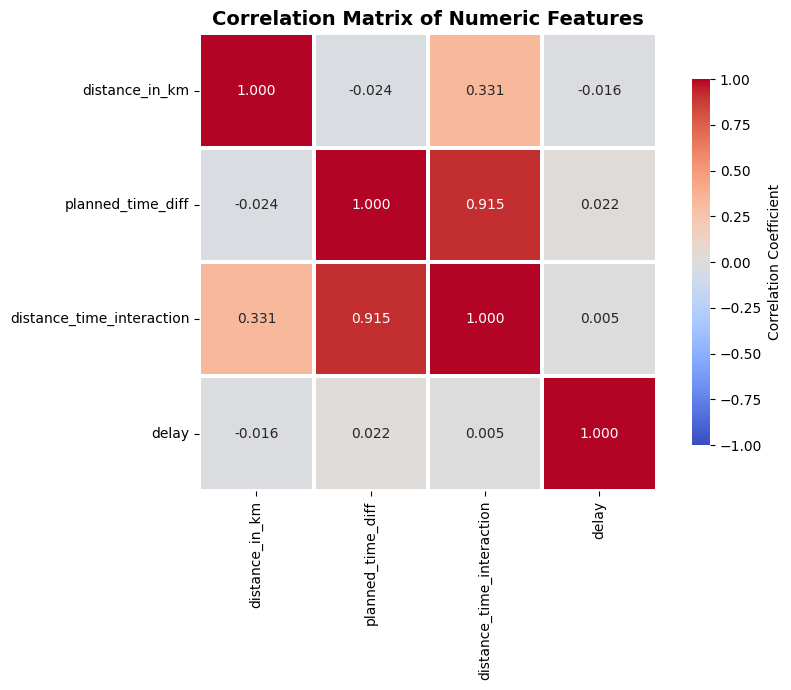


Correlation with delay:
planned_time_diff            0.022312
distance_time_interaction    0.005187
distance_in_km              -0.016064
Name: delay, dtype: float64


In [27]:
# Correlation matrix
numeric_cols = ["distance_in_km", "planned_time_diff", "distance_time_interaction", "delay"]
corr_matrix = filtered_train_moments_df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"})
plt.title("Correlation Matrix of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_4_9_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nCorrelation with delay:")
print(corr_matrix["delay"].drop("delay").sort_values(ascending=False))

## 5f. Categorical breakdowns

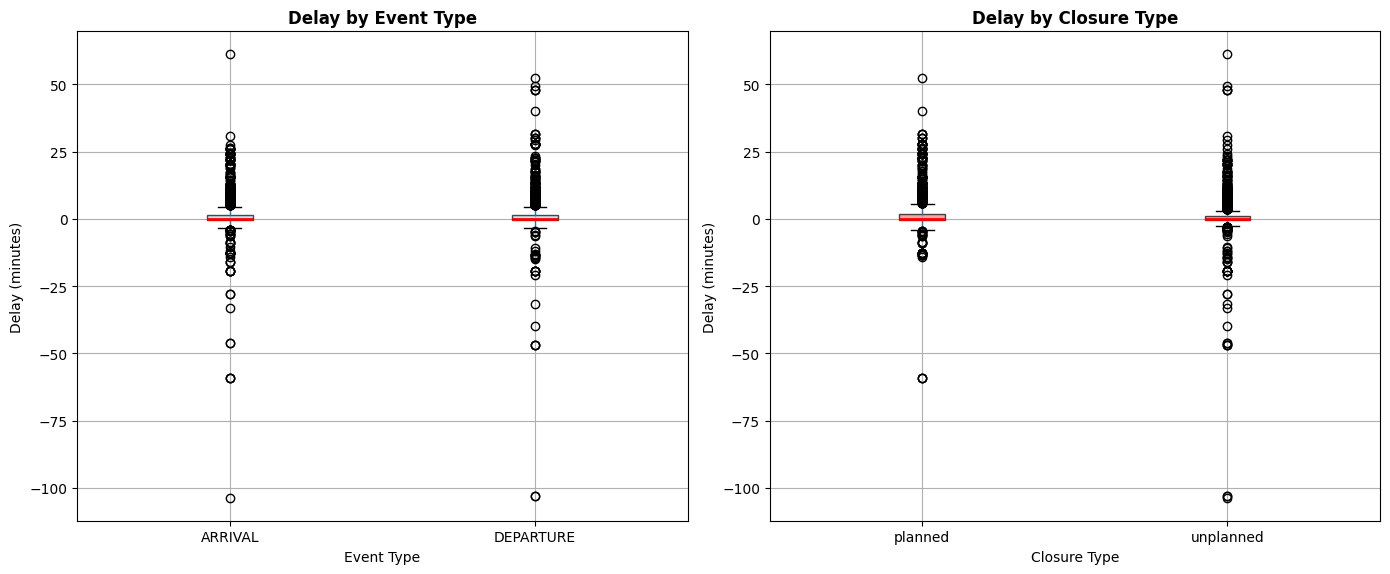


Mean delay by event type:
                mean  median       std  count
event_type                                   
ARRIVAL     1.003122     0.0  5.661334   2402
DEPARTURE   1.080613     0.0  5.899984   2512


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

filtered_train_moments_df.boxplot(column="delay", by="event_type", ax=axes[0],
    patch_artist=True, boxprops=dict(facecolor="lightblue", alpha=0.7),
    medianprops=dict(color="red", linewidth=2))
axes[0].set_title("Delay by Event Type", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Event Type")
axes[0].set_ylabel("Delay (minutes)")

if filtered_train_moments_df["closure_type"].nunique() > 1:
    filtered_train_moments_df.boxplot(column="delay", by="closure_type", ax=axes[1],
        patch_artist=True, boxprops=dict(facecolor="lightcoral", alpha=0.7),
        medianprops=dict(color="red", linewidth=2))
    axes[1].set_title("Delay by Closure Type", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Closure Type")
    axes[1].set_ylabel("Delay (minutes)")
else:
    axes[1].text(0.5, 0.5, "Only one closure type\n(zero variance)", ha="center",
                 va="center", transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("Closure Type — Zero Variance")

plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/fig_4_10_delay_by_categories.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nMean delay by event type:")
print(filtered_train_moments_df.groupby("event_type")["delay"].agg(["mean", "median", "std", "count"]))

## 5g. Temporal patterns

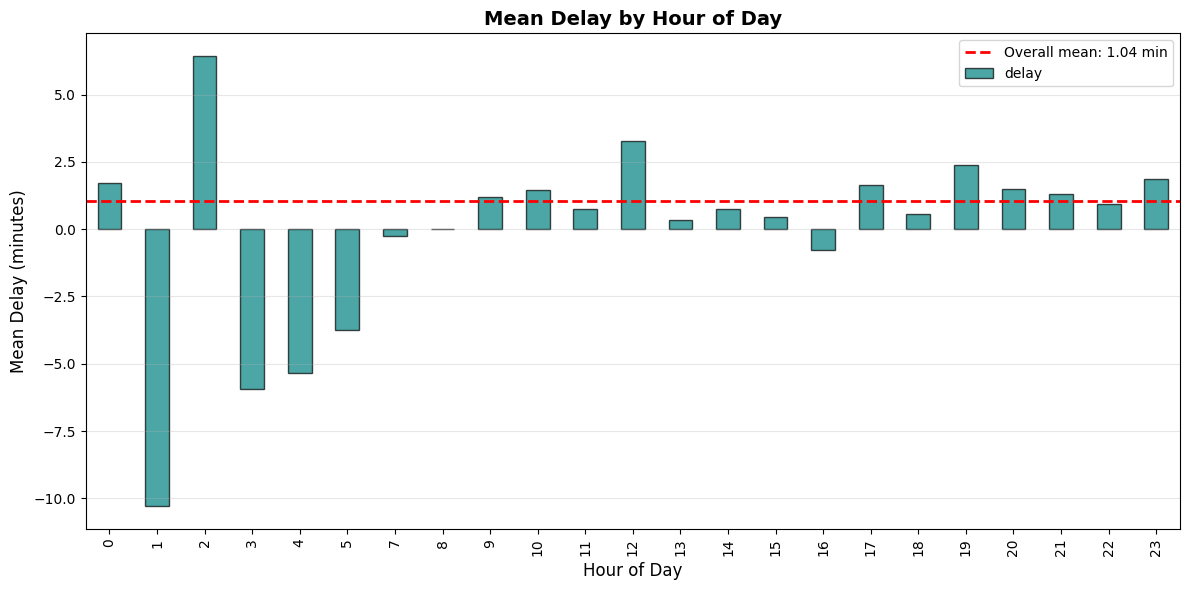

In [29]:
filtered_train_moments_df["hour"] = filtered_train_moments_df["planned_timestamp"].dt.hour
hourly = filtered_train_moments_df.groupby("hour")["delay"].mean()

plt.figure(figsize=(12, 6))
hourly.plot(kind="bar", color="teal", edgecolor="black", alpha=0.7)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Mean Delay (minutes)", fontsize=12)
plt.title("Mean Delay by Hour of Day", fontsize=14, fontweight="bold")
plt.axhline(filtered_train_moments_df["delay"].mean(), color="red", linestyle="--", lw=2,
            label=f'Overall mean: {filtered_train_moments_df["delay"].mean():.2f} min')
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_4_11_delay_by_hour.png", dpi=300, bbox_inches="tight")
plt.show()

## 5h. Station analysis

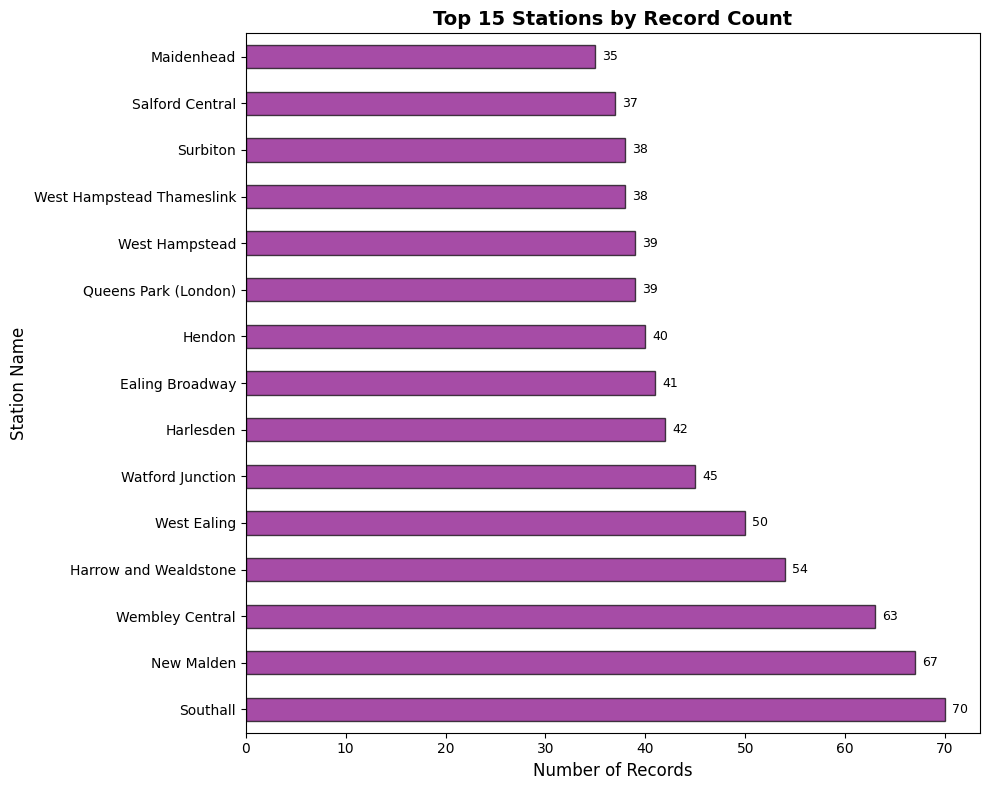

Top 15 stations: 698 rows (14.2% of total)


In [30]:
top_stations = filtered_train_moments_df["station_name"].value_counts().head(15)

plt.figure(figsize=(10, 8))
top_stations.plot(kind="barh", color="purple", edgecolor="black", alpha=0.7)
plt.xlabel("Number of Records", fontsize=12)
plt.ylabel("Station Name", fontsize=12)
plt.title("Top 15 Stations by Record Count", fontsize=14, fontweight="bold")
for i, v in enumerate(top_stations.values):
    plt.text(v + max(top_stations) * 0.01, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figures/fig_4_12_top_stations.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Top 15 stations: {top_stations.sum():,} rows "
      f"({top_stations.sum()/len(filtered_train_moments_df)*100:.1f}% of total)")

<Figure size 1400x700 with 0 Axes>

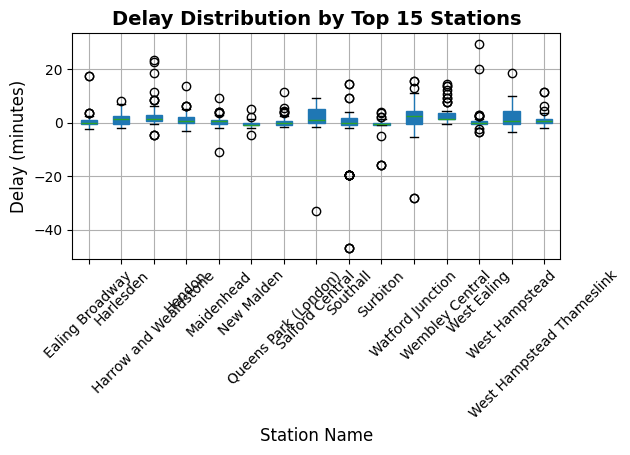

In [31]:
top_names = filtered_train_moments_df["station_name"].value_counts().head(15).index
top_data = filtered_train_moments_df[filtered_train_moments_df["station_name"].isin(top_names)]

plt.figure(figsize=(14, 7))
top_data.boxplot(column="delay", by="station_name", rot=45, patch_artist=True)
plt.suptitle("")
plt.title("Delay Distribution by Top 15 Stations", fontsize=14, fontweight="bold")
plt.xlabel("Station Name", fontsize=12)
plt.ylabel("Delay (minutes)", fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig_4_13_delay_by_station_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

Unique closures: 125
Mean rows per closure: 39.3
Median rows per closure: 13.0


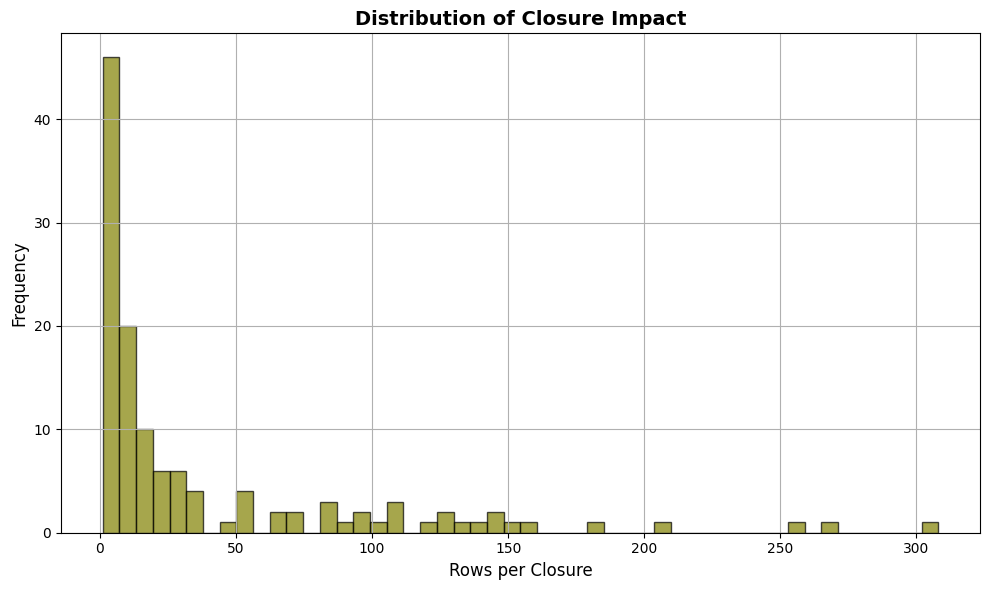

In [32]:
# Closure impact distribution
if "closure_id" in filtered_train_moments_df.columns:
    closure_counts = filtered_train_moments_df.groupby("closure_id").size().sort_values(ascending=False)
    print(f"Unique closures: {len(closure_counts)}")
    print(f"Mean rows per closure: {closure_counts.mean():.1f}")
    print(f"Median rows per closure: {closure_counts.median():.1f}")

    plt.figure(figsize=(10, 6))
    closure_counts.hist(bins=50, edgecolor="black", alpha=0.7, color="olive")
    plt.xlabel("Rows per Closure", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title("Distribution of Closure Impact", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/fig_4_14_closure_impact_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

## 6. Model training

In [33]:
features = [
    "distance_in_km",
    "planned_time_diff",
    "closure_type",
    "event_type",
    "distance_time_interaction",
]

X = filtered_train_moments_df[features]
y = filtered_train_moments_df["delay"]

# Time-based split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test:  {len(X_test):,} rows ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nTrain delay — mean: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"Test delay  — mean: {y_test.mean():.3f}, std: {y_test.std():.3f}")

Train: 3,931 rows (80%)
Test:  983 rows (20%)

Train delay — mean: 1.104, std: 6.011
Test delay  — mean: 0.796, std: 4.767


C:\Users\patil\AppData\Local\Temp\ipykernel_42656\1291755018.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([y_train, y_test], labels=["Train", "Test"], patch_artist=True,


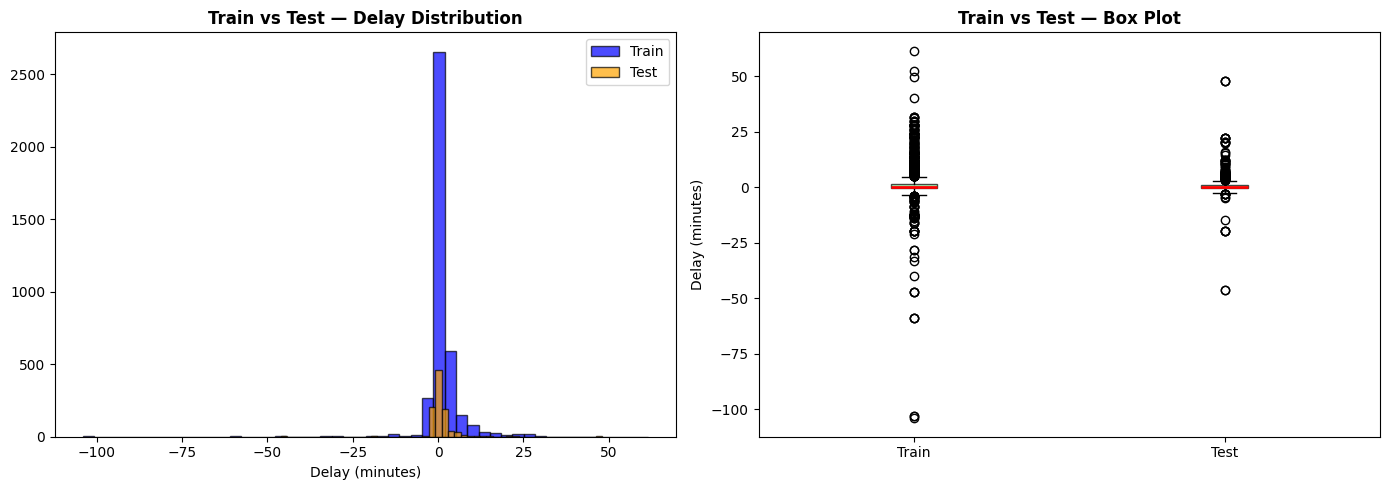

In [34]:
# Train/test distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50, alpha=0.7, label="Train", color="blue", edgecolor="black")
axes[0].hist(y_test, bins=50, alpha=0.7, label="Test", color="orange", edgecolor="black")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_title("Train vs Test — Delay Distribution", fontweight="bold")
axes[0].legend()

axes[1].boxplot([y_train, y_test], labels=["Train", "Test"], patch_artist=True,
                boxprops=dict(facecolor="lightgreen", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Delay (minutes)")
axes[1].set_title("Train vs Test — Box Plot", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig_4_15_train_test_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, explained_variance_score,
    mean_absolute_percentage_error,
)
import time as timer

# Preprocessor
categorical_cols = ["closure_type", "event_type"]
numeric_cols = ["distance_in_km", "planned_time_diff", "distance_time_interaction"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols),
])

# Models
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42,
    ),
    "XGBoost_tuned": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1, random_state=42,
    ),
}

In [36]:
# Train and evaluate all models
results = []

for name, model_obj in models.items():
    pipeline = Pipeline([("prep", preprocessor), ("model", model_obj)])

    t0 = timer.time()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    elapsed = timer.time() - t0

    print(f"Trained {name} in {elapsed:.2f}s")

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "MedianAE": median_absolute_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "ExplainedVar": explained_variance_score(y_test, y_pred),
        "pipeline": pipeline,
    })

results_df = pd.DataFrame(results)
results_df[["model", "MAE", "RMSE", "R2", "MedianAE", "MAPE", "ExplainedVar"]]

Trained Linear in 0.12s
Trained RandomForest in 2.50s
Trained GradientBoosting in 0.83s
Trained XGBoost in 0.68s
Trained XGBoost_tuned in 0.95s


,model,MAE,RMSE,R2,MedianAE,MAPE,ExplainedVar
0,Linear,1.982317,4.744952,0.008158,1.021091,4.141632e+14,0.011732
1,RandomForest,2.732946,5.764523,-0.463881,1.485000,1.583146e+15,-0.459084
2,GradientBoosting,2.477173,5.814109,-0.489173,1.316660,1.471628e+15,-0.486163
3,XGBoost,3.016806,6.293389,-0.744810,1.585093,1.842030e+15,-0.729140
4,XGBoost_tuned,2.872172,5.984091,-0.577522,1.571069,1.813884e+15,-0.565484


## 6a. Model comparison charts

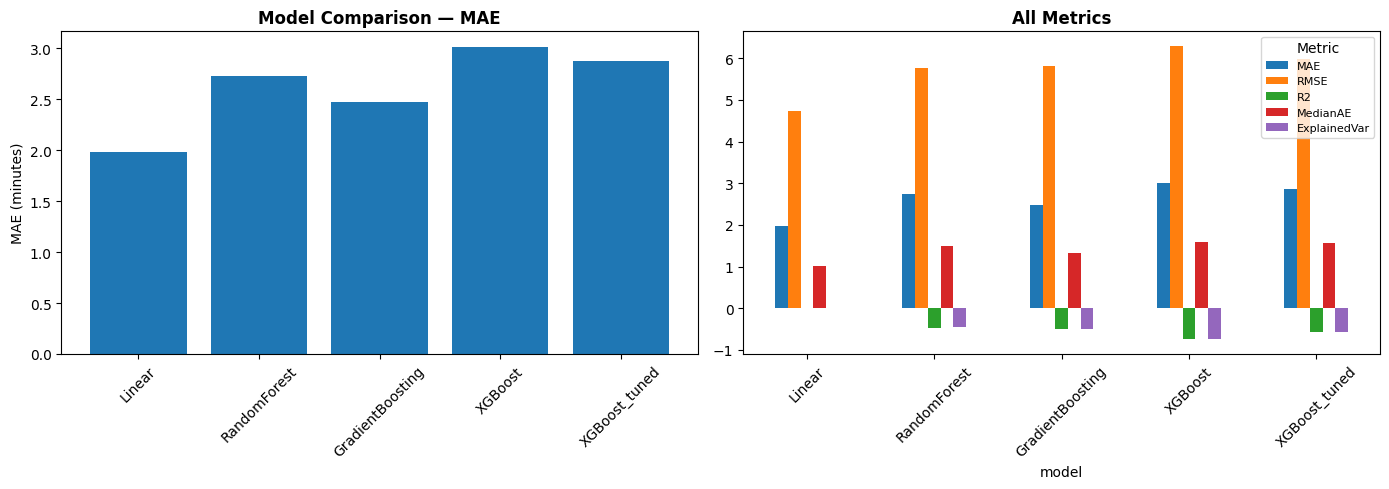

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results_df["model"], results_df["MAE"])
axes[0].set_title("Model Comparison — MAE", fontweight="bold")
axes[0].set_ylabel("MAE (minutes)")
axes[0].tick_params(axis="x", rotation=45)

metrics = ["MAE", "RMSE", "R2", "MedianAE", "ExplainedVar"]
results_df.set_index("model")[metrics].plot(kind="bar", ax=axes[1])
axes[1].set_title("All Metrics", fontweight="bold")
axes[1].legend(title="Metric", fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/fig_5_1_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Best model diagnostics

Best model: Linear (MAE=1.982)


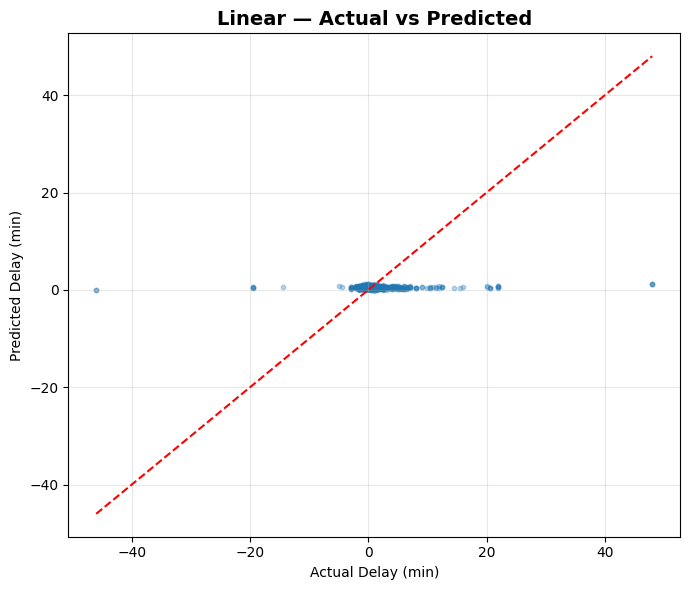

In [38]:
best_row = results_df.sort_values("MAE").iloc[0]
best_model = best_row["pipeline"]
best_name = best_row["model"]
print(f"Best model: {best_name} (MAE={best_row['MAE']:.3f})")

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Delay (min)")
plt.ylabel("Predicted Delay (min)")
plt.title(f"{best_name} — Actual vs Predicted", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_5_2_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

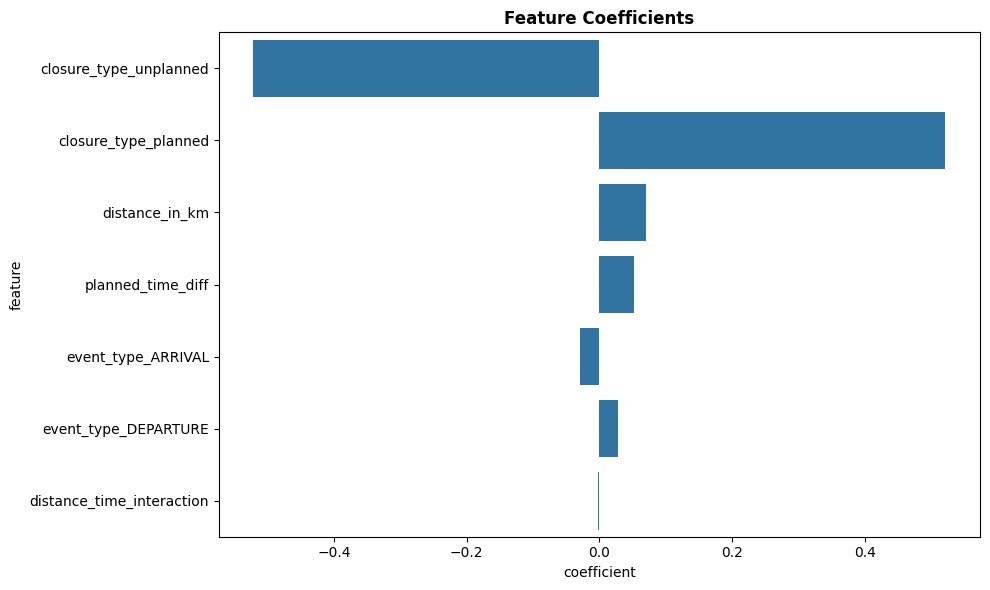

,feature,coefficient
1,closure_type_unplanned,-0.521738
0,closure_type_planned,0.521738
4,distance_in_km,0.070601
5,planned_time_diff,0.052665
2,event_type_ARRIVAL,-0.028517
3,event_type_DEPARTURE,0.028517
6,distance_time_interaction,-0.002677


In [39]:
# Feature importance / coefficients
inner_model = best_model.named_steps["model"]
ohe = best_model.named_steps["prep"].named_transformers_["cat"]
feature_names = list(ohe.get_feature_names_out(categorical_cols)) + numeric_cols

if hasattr(inner_model, "feature_importances_"):
    imp_df = pd.DataFrame({"feature": feature_names, "importance": inner_model.feature_importances_})
    imp_df = imp_df.sort_values("importance", ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x="importance", y="feature")
    plt.title("Feature Importance", fontweight="bold")
elif hasattr(inner_model, "coef_"):
    imp_df = pd.DataFrame({"feature": feature_names, "coefficient": inner_model.coef_})
    imp_df = imp_df.sort_values("coefficient", key=abs, ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x="coefficient", y="feature")
    plt.title("Feature Coefficients", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig_5_3_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
display(imp_df)

## 8. Predict future delays (timetable)

In [50]:
X_future = filtered_timetable_df[features]
filtered_timetable_df["predicted_delay"] = best_model.predict(X_future)

filtered_columns =[
    "closure_type", "station_name", "distance_in_km",
    "closure_start_time", "planned_timestamp", "planned_time_diff", "predicted_delay",]
print(f"Total filtered timetable: {len(filtered_timetable_df):,} rows")
filtered_timetable_df[filtered_columns].head(10)

Total filtered timetable: 184,592 rows


,closure_type,station_name,distance_in_km,closure_start_time,planned_timestamp,planned_time_diff,predicted_delay
0,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 20:00:00,60.0,1.352830
17,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 19:21:30,21.5,1.547148
105,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 19:22:00,22.0,1.601658
106,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 19:00:30,0.5,1.710173
312,planned,Ely,21.974512,2026-04-11 19:00:00,2026-04-11 19:16:00,16.0,1.586366
313,planned,Ely,21.974512,2026-04-11 19:00:00,2026-04-11 19:51:00,51.0,1.371068
325,planned,Ely,21.974512,2026-04-11 19:00:00,2026-04-11 19:14:00,14.0,1.598669
363,planned,Ely,21.974512,2026-04-11 19:00:00,2026-04-11 19:19:00,19.0,1.567912
400,planned,Ely,21.974512,2026-04-11 19:00:00,2026-04-11 19:48:00,48.0,1.389522
466,planned,Ely,21.974512,2026-04-11 19:00:00,2026-04-11 19:07:00,7.0,1.641728


In [65]:
planned_df = filtered_timetable_df[filtered_timetable_df["closure_type"] == "planned"]
unplanned_df = filtered_timetable_df[filtered_timetable_df["closure_type"] == "unplanned"]

print(f"Planned closures: {len(planned_df):,} rows")
display(planned_df[filtered_columns].head())

print(f"Unplanned closures: {len(unplanned_df):,} rows")
display(unplanned_df[filtered_columns].head())


Planned closures: 77,774 rows


,closure_type,station_name,distance_in_km,closure_start_time,planned_timestamp,planned_time_diff,predicted_delay
0,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 20:00:00,60.0,1.352830
17,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 19:21:30,21.5,1.547148
105,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 19:22:00,22.0,1.601658
106,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 19:00:30,0.5,1.710173
312,planned,Ely,21.974512,2026-04-11 19:00:00,2026-04-11 19:16:00,16.0,1.586366


Unplanned closures: 106,818 rows


,closure_type,station_name,distance_in_km,closure_start_time,planned_timestamp,planned_time_diff,predicted_delay
7788342,unplanned,Acton Central,20.4733,2026-04-10 16:27:32.320,2026-04-10 16:31:30,3.961333,0.526874
7788343,unplanned,Acton Central,20.4733,2026-04-10 16:27:32.320,2026-04-10 16:43:00,15.461333,0.502342
7788344,unplanned,Acton Central,20.4733,2026-04-10 16:27:32.320,2026-04-10 16:55:00,27.461333,0.476743
7788345,unplanned,Acton Central,20.4733,2026-04-10 16:27:32.320,2026-04-10 17:07:00,39.461333,0.451144
7788366,unplanned,Acton Central,20.4733,2026-04-10 16:27:32.320,2026-04-10 16:29:30,1.961333,0.531141


In [67]:
# Create 1‑minute bins from 0 to 60
bins = list(range(0, 62, 1))   # 0,1,2,3,...60,61
labels = [f"{i}-{i+1} mins" for i in range(0, 61)]


filtered_timetable_df["delay_bucket"] = pd.cut(
    filtered_timetable_df["predicted_delay"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)


In [68]:
bucket_summary = (
    filtered_timetable_df
    .groupby(["closure_type", "delay_bucket"])
    .size()
    .reset_index(name="count")
    .sort_values(["closure_type", "delay_bucket"])
)

bucket_summary


,closure_type,delay_bucket,count
0,planned,0-1 mins,228
1,planned,1-2 mins,75115
2,planned,2-3 mins,2431
3,unplanned,0-1 mins,104593
4,unplanned,1-2 mins,1804


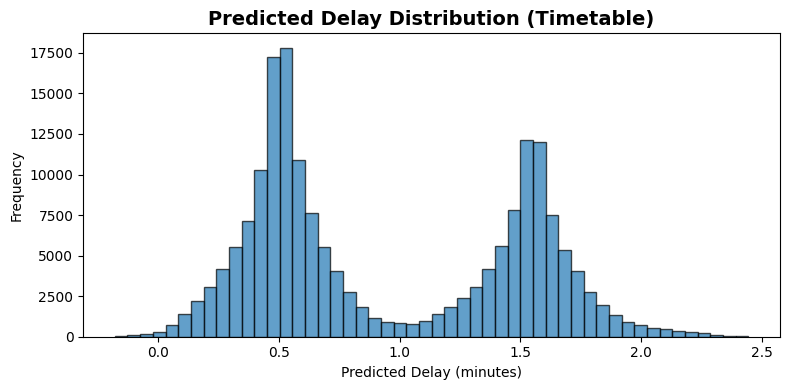

In [41]:
plt.figure(figsize=(8, 4))
plt.hist(filtered_timetable_df["predicted_delay"], bins=50, edgecolor="black", alpha=0.7)
plt.title("Predicted Delay Distribution (Timetable)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Delay (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/fig_5_4_predicted_delay_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Station-level validation

In [42]:
# Match timetable predictions to actual train movements
comparison_df = pd.merge_asof(
    filtered_timetable_df.sort_values("planned_timestamp"),
    filtered_train_moments_df.sort_values("planned_timestamp"),
    on="planned_timestamp",
    by="station_name",
    direction="nearest",
    tolerance=pd.Timedelta("20min"),
)

match_rate = comparison_df["actual_timestamp"].notna().mean()
print(f"Total timetable rows: {len(filtered_timetable_df):,}")
print(f"Matched rows: {comparison_df['actual_timestamp'].notna().sum():,}")
print(f"Match rate: {match_rate:.2%}")

Total timetable rows: 184,592
Matched rows: 47,970
Match rate: 25.99%


Aggregated station-level MAE: 2.064 minutes


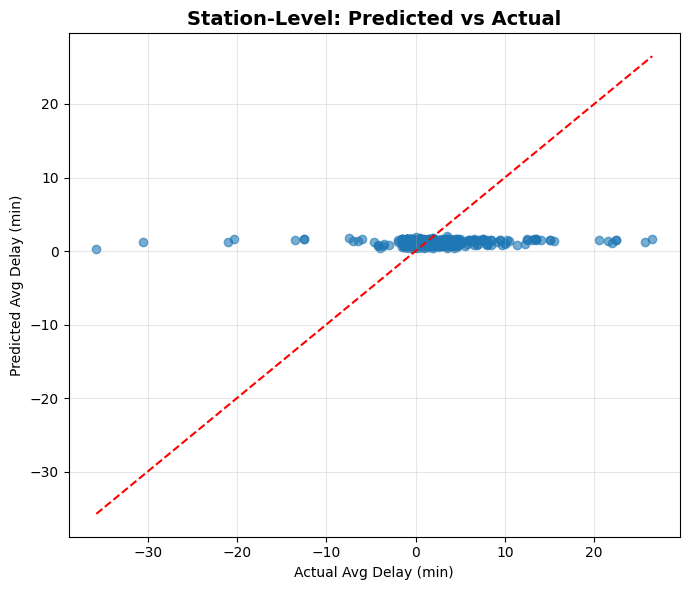

,predicted_delay,actual_delay
station_name,,
Abbey Wood,0.802727,-1.000000
Accrington,1.450533,1.500000
Acle,1.693897,-0.750000
Acton Bridge (Cheshire),1.365716,0.250000
Acton Central,0.767319,3.785714
...,...,...
Worplesdon,0.894591,0.000000
Wraysbury,0.780009,-0.500000
Wylde Green,1.266259,0.500000


In [43]:
# Station-level aggregated comparison
filtered_train_moments_df["actual_delay"] = filtered_train_moments_df["delay"]

pred_summary = filtered_timetable_df.groupby("station_name")["predicted_delay"].mean()
actual_summary = filtered_train_moments_df.groupby("station_name")["actual_delay"].mean()

comparison = pd.concat([pred_summary, actual_summary], axis=1).dropna()

from sklearn.metrics import mean_absolute_error
agg_mae = mean_absolute_error(comparison["actual_delay"], comparison["predicted_delay"])
print(f"Aggregated station-level MAE: {agg_mae:.3f} minutes")

plt.figure(figsize=(7, 6))
plt.scatter(comparison["actual_delay"], comparison["predicted_delay"], alpha=0.6)
mn, mx = comparison.min().min(), comparison.max().max()
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("Actual Avg Delay (min)")
plt.ylabel("Predicted Avg Delay (min)")
plt.title("Station-Level: Predicted vs Actual", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_5_5_station_level_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

display(comparison)